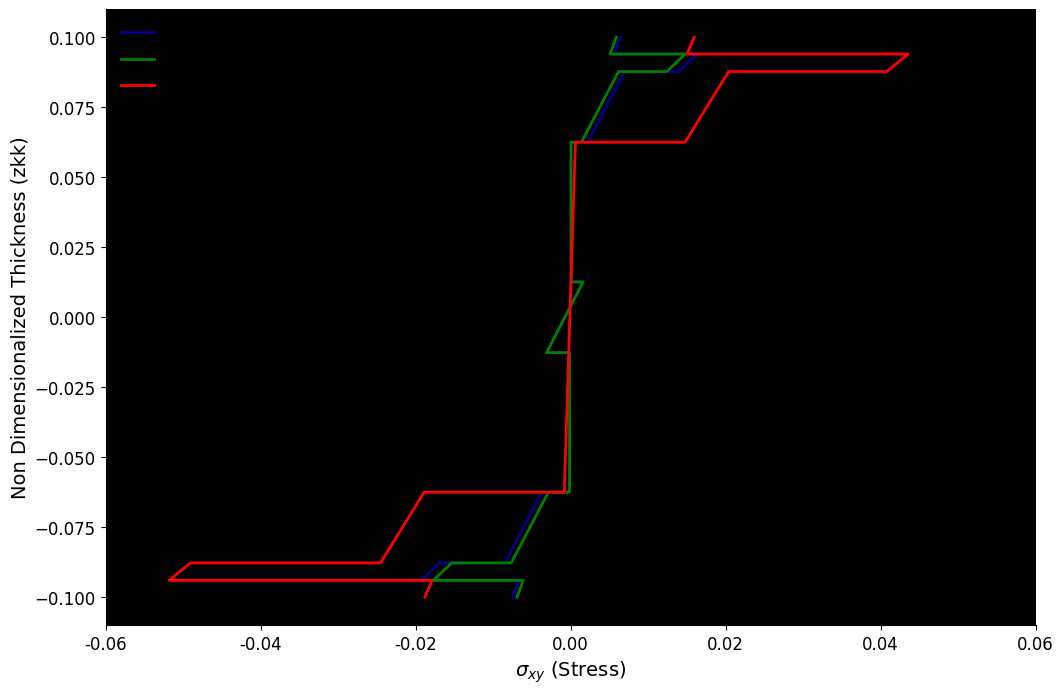

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to parse sections of the file into a DataFrame
def parse_section(lines, start, end):
    section_data = lines[start:end]
    df = pd.DataFrame([x.split() for x in section_data if x.strip()], columns=['sxy', 'zkk'])
    df['sxy'] = pd.to_numeric(df['sxy'], errors='coerce')
    df['zkk'] = pd.to_numeric(df['zkk'], errors='coerce')
    return df

# Load and read the file
data_path = "C:\\Users\\yashd\\Downloads\\data.txt" # Update this to the actual file path
with open(data_path, 'r') as file:
    lines = file.readlines()

# Identify the indices where new layer sections start
indices = [i for i, line in enumerate(lines) if 'layer' in line]
indices.append(len(lines))  # Append the end of the file for the last section

# Parsing each section
eleven_layer_data = parse_section(lines, indices[0]+1, indices[1])
five_layer_data = parse_section(lines, indices[1]+1, indices[2])
three_layer_data = parse_section(lines, indices[2]+1, indices[3])


# Plotting all layers on one graph
plt.figure(figsize=(12, 8))
plt.plot(eleven_layer_data['sxy'], eleven_layer_data['zkk'], label='11-layer', marker='', linestyle='-', color='darkblue', linewidth=2)
plt.plot(five_layer_data['sxy'], five_layer_data['zkk'], label='5-layer', marker='', linestyle='-', color='green', linewidth=2)
plt.plot(three_layer_data['sxy'], three_layer_data['zkk'], label='3-layer', marker='', linestyle='-', color='red', linewidth=2)

# plt.title('Stress Distribution for Composite Materials', fontsize=16)
plt.xlabel(r'$\sigma_{xy}$ (Stress)', fontsize=14)  # Using LaTeX for sigma symbol
plt.ylabel('Non Dimensionalized Thickness (zkk)', fontsize=14)
plt.legend(fontsize=12, frameon=False)  # No frame around legend
plt.grid(False)  # No grid
plt.gca().set_facecolor('white')  # White background

# Removing top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust x-axis ticks interval
plt.xticks(ticks=plt.xticks()[0], labels=[f"{tick:.2f}" for tick in plt.xticks()[0]])

# Increasing all text sizes
plt.rc('font', size=12)  # controls default text sizes
plt.rc('axes', titlesize=16)  # fontsize of the axes title
plt.rc('axes', labelsize=14)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)  # fontsize of the tick labels
plt.rc('ytick', labelsize=12)  # fontsize of the tick labels
plt.rc('legend', fontsize=12)  # legend fontsize

# Show the plot
plt.show()
